# RANSAC Empirical Analysis
**CS5008 Final Project — Arsh Singh**

This notebook runs all three experiments and generates plots for the report.

---
## 1. Setup and Imports

In [3]:
import sys
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# output directory for saved figures
import os
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = '../results'
os.makedirs(DATA_DIR, exist_ok=True)

# Column rename dictionary shared across all three experiments.
# Apply with: df.rename(columns=COL_NAMES, inplace=True)

COL_NAMES = {
    'index':       'Run Index',
    'n':           'Total Points (N)',
    'epsilon':     'Outlier Fraction (ε)',
    'd':           'Expected Inliers (d)',
    'm':           'Model Parameters (m)',
    'k':           'Iterations Used (k)',
    'k_budget':    'Iteration Budget (k)',
    'k_theory':    'Iterations Required by Theory',
    't':           'Inlier Threshold (t)',
    'pr':          'Bias Probability (pr)',
    'bias_type':   'Bias Type',
    'repeat':      'Repeat Number',
    'time_mu_s':   'Wall-Clock Time (μs)',
    'model_error': 'Model Error (Euclidean)',
}
print('Setup complete.')

Setup complete.


---
## Experiment 1 — How Does RANSAC Break Down as Outlier Fraction Increases?

Fix $k$ at the value computed for $\varepsilon = 0.5$. Vary $\varepsilon$ from 0.1 to 0.9.
Run for linear ($m=2$) and quadratic ($m=3$) models. `N` is 1000. Repeat `N_REPEATS` times.

In [4]:
df1 = pd.read_csv('results/exp1.csv').rename(columns=COL_NAMES)
df1.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9992,0,397.0,0.112070
1,1,1000,0.05,950,2,17,1.0011,1,349.0,0.090577
2,2,1000,0.05,950,2,17,0.9663,2,390.0,0.190570
3,3,1000,0.05,950,2,17,0.9853,3,340.0,0.089918
4,4,1000,0.05,950,2,17,1.0075,4,392.0,0.075750


In [13]:
agg1 = (df1.groupby(['Model Parameters (m)', 'Outlier Fraction (ε)'])
           ['Model Error (Euclidean)']
           .agg(mean_error='mean', std_error='std', count='count')
           .reset_index())

In [14]:
# breakdown threshold — model error greater than twice noise std
BREAKDOWN_THRESHOLD = 2 * 0.5   # 2 * NOISE_STD

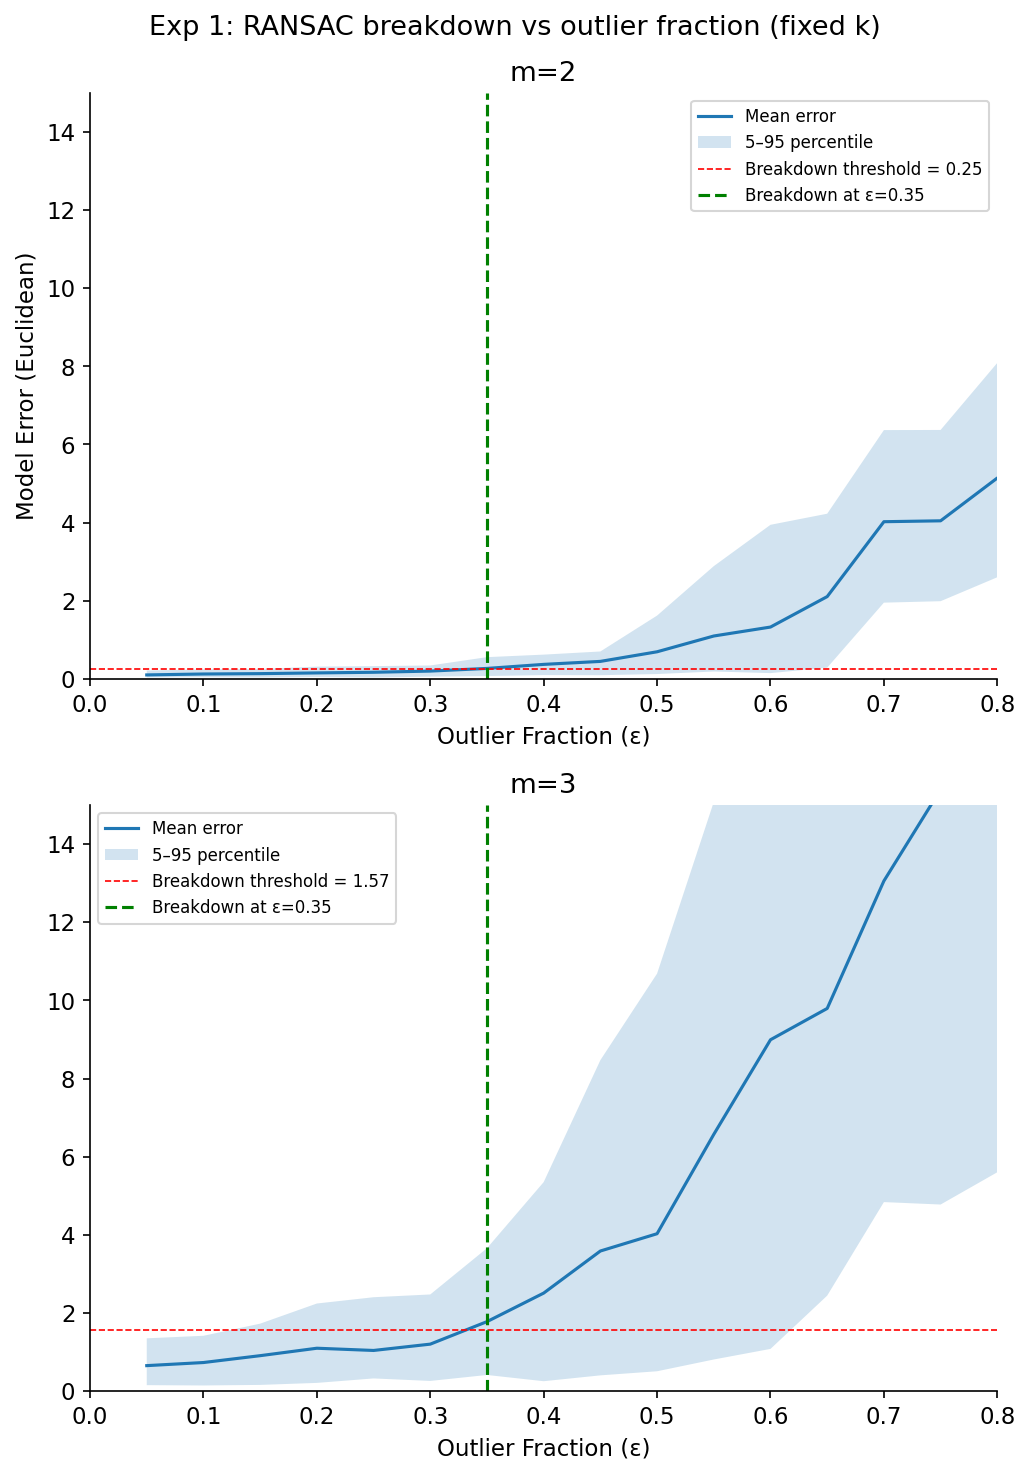

In [22]:
models = df1["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), 1, figsize=(7, 10))

for i, m in enumerate(models):
    ax  = axes[i]
    sub = df1[df1["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]

    means = grp.mean()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    baseline_mean = means.iloc[0]
    baseline_std  = grp.std().iloc[0]
    threshold     = baseline_mean + 2 * baseline_std

    ax.plot(means.index, means.values, label="Mean error")
    ax.fill_between(means.index, lower, upper, alpha=0.2, label="5–95 percentile")
    ax.axhline(threshold, color="red", linestyle="--",
               linewidth=0.8, label=f"Breakdown threshold = {threshold:.2f}")

    breakdown_rows = means[means > threshold]
    if not breakdown_rows.empty:
        breakdown_eps = breakdown_rows.index[0]
        ax.axvline(x=breakdown_eps, color="green", linestyle="--",
                   label=f"Breakdown at ε={breakdown_eps:.2f}")

    ax.set_title(f"m={m}")
    ax.set_xlabel("Outlier Fraction (ε)")
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 15)
    if i == 0:
        ax.set_ylabel("Model Error (Euclidean)")
    ax.legend(fontsize=8)

plt.suptitle("Exp 1: RANSAC breakdown vs outlier fraction (fixed k)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp1_outlier_fraction.png", dpi=150)
plt.show()

---
## Experiment 2 — At What Structural Bias Probability Does RANSAC Fail?

Fix $\varepsilon = 0.3$. Vary $p_r$ from 0.0 to 1.0 in steps of 0.1.
Three bias types: constant, linear, periodic. Linear and quadratic models. `N` is 1000. Repeat `N_REPEATS` times.

In [16]:
df2 = pd.read_csv('results/exp2.csv').rename(columns=COL_NAMES)
df2.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Bias Probability (pr),Bias Type,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.1,900,2,17,0.9968,0.0,constant,0,390.0,0.179528
1,1,1000,0.1,900,2,17,0.9949,0.0,constant,1,364.0,0.052584
2,2,1000,0.1,900,2,17,0.9802,0.0,constant,2,353.0,0.341749
3,3,1000,0.1,900,2,17,1.0058,0.0,constant,3,354.0,0.226147
4,4,1000,0.1,900,2,17,0.9708,0.0,constant,4,338.0,0.153389


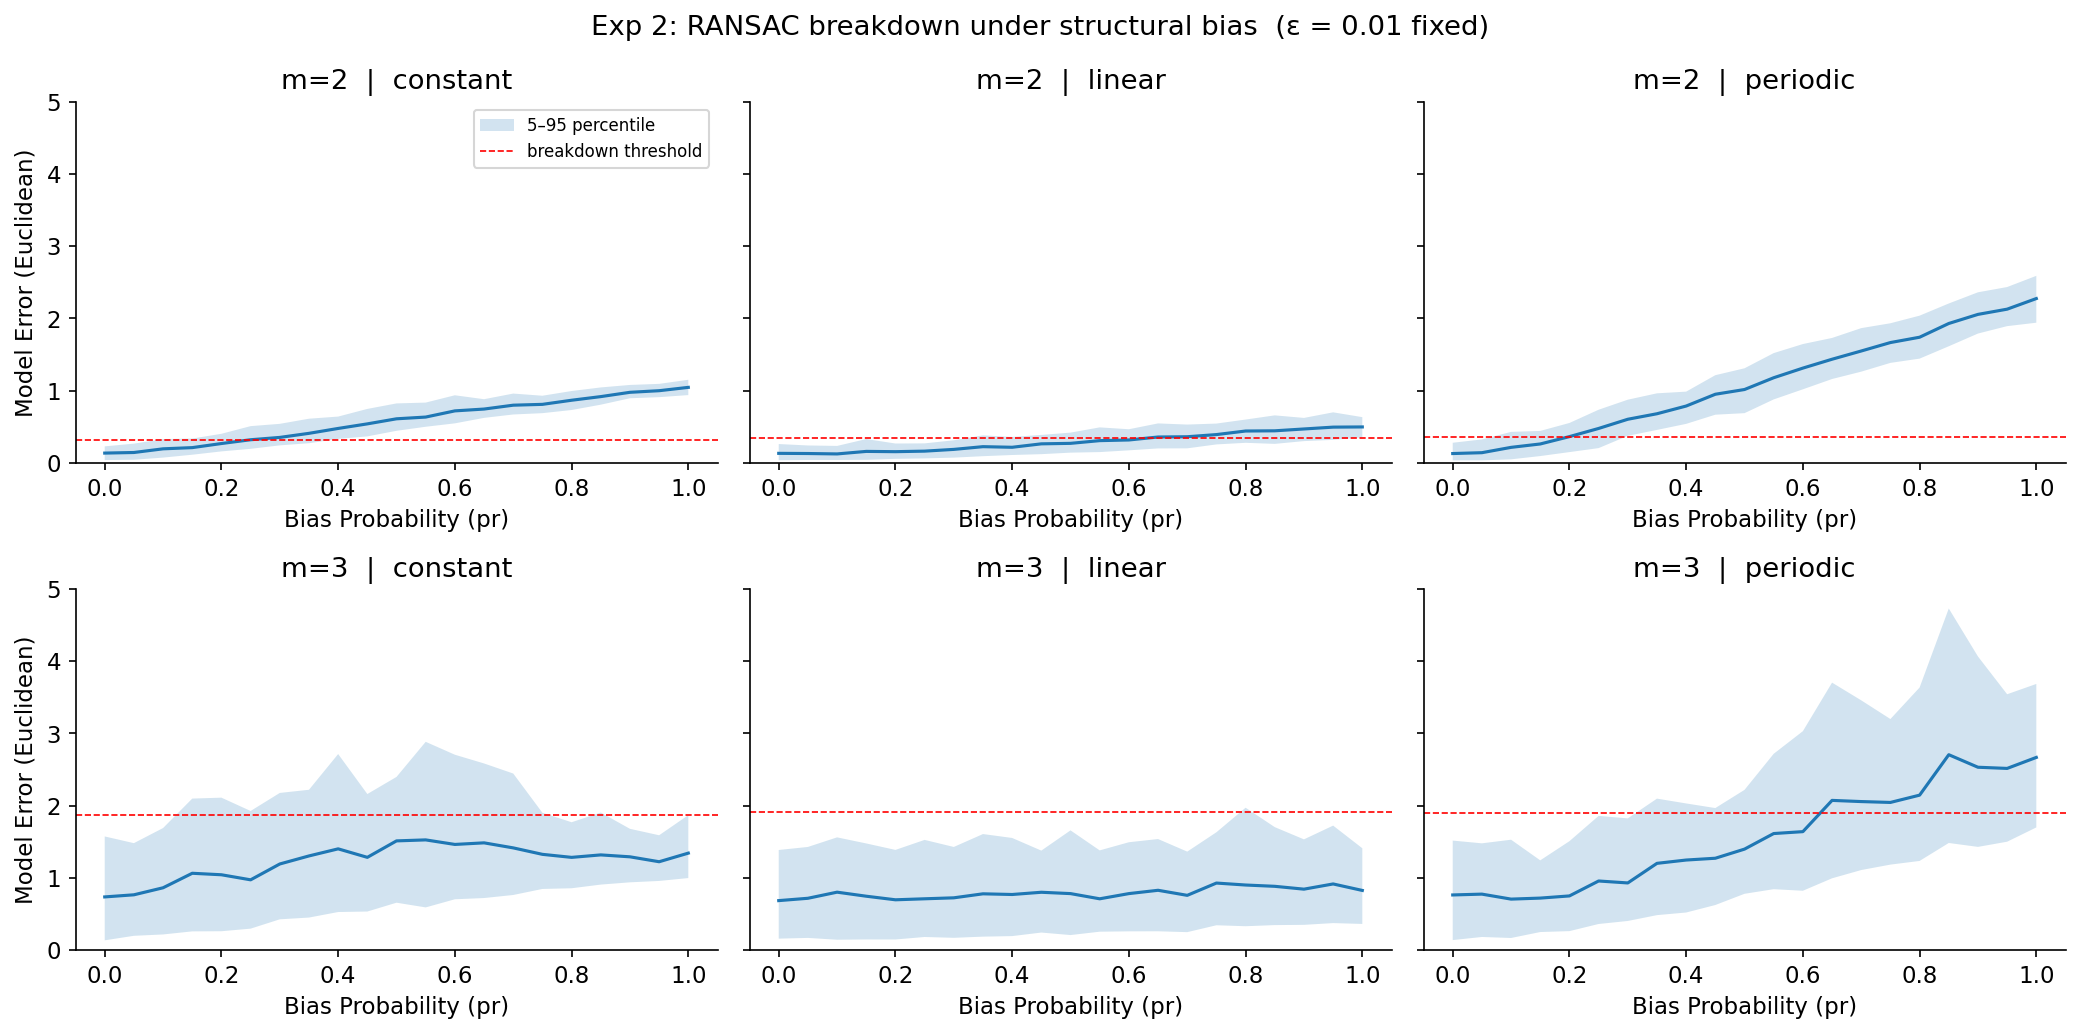

In [23]:
bias_types = df2["Bias Type"].unique()
models     = df2["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), len(bias_types),
                         figsize=(14, 7), sharey=True)

for i, m in enumerate(models):
    for j, bias in enumerate(bias_types):
        ax  = axes[i, j]
        sub = df2[(df2["Model Parameters (m)"] == m) &
                  (df2["Bias Type"] == bias)]
        grp = sub.groupby("Bias Probability (pr)")["Model Error (Euclidean)"]

        means = grp.mean()
        stds  = grp.std()
        lower = grp.quantile(0.10)
        upper = grp.quantile(0.90)

        baseline_mean = means.loc[0.0]
        baseline_std  = stds.loc[0.0]
        threshold     = baseline_mean + 2 * baseline_std

        ax.plot(means.index, means.values)
        ax.fill_between(means.index, lower, upper, alpha=0.2, label='5–95 percentile')
        ax.axhline(threshold, color='red', linestyle='--',
                   linewidth=0.8, label='breakdown threshold')

        ax.set_title(f"m={m}  |  {bias}")
        ax.set_xlabel("Bias Probability (pr)")
        ax.set_ylim(0, 5)
        if j == 0:
            ax.set_ylabel("Model Error (Euclidean)")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Exp 2: RANSAC breakdown under structural bias  (ε = 0.01 fixed)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp2.png", dpi=150)
plt.show()

---
## Experiment 3 — At What Model Degree Does RANSAC Fail for a Budgeted or Fixed Iteration Count?

Fix $\varepsilon = 0.1$. Vary $m$ from 2 to 11 in steps of 1. Run twice for $k$ = 100 and $k$ = 1000. `N` is 1000. Repeat `N_REPEATS` times.
